# **A/B Testing: Optimizing Retention in Cookie Cats**
### End-to-end A/B testing analysis including hypothesis testing, retention analysis, and business recommendation.

# 🎮 Project Overview

**Cookie Cats** is a popular mobile puzzle game developed by Tactile Entertainment.
Players progress through levels by solving “match-three” puzzles.

Before diving into the A/B testing analysis, here’s a quick look at the gameplay:

[![Watch Gameplay](https://img.youtube.com/vi/0G-612U2vQY/0.jpg)](https://www.youtube.com/watch?v=0G-612U2vQY)

To control pacing and monetization, the game introduces **gates** that:

* force players to wait, or
* encourage in-app purchases

---

## 🎯 Experiment Goal

This project analyzes an A/B test where:

* **Control Group:** Gate at level 30 (`gate_30`)
* **Treatment Group:** Gate moved to level 40 (`gate_40`)

---

# 📊 Dataset Description

The dataset contains data from **90,189 players** during the experiment.

### Variables:

* **userid** → Unique player identifier
* **version** → Experiment group (`gate_30` vs `gate_40`)
* **sum_gamerounds** → Total rounds played in the first 7 days
* **retention_1** → Returned after 1 day (binary)
* **retention_7** → Returned after 7 days (binary)

Source: https://www.kaggle.com/yufengsui

📌 Note:
Users were **randomly assigned**, ensuring valid A/B test conditions.

---

# 🧪 A/B Testing Framework

This project follows a structured experimentation workflow:

## 1. Problem Understanding

* Define business objective
* Identify key metrics (retention, engagement)

## 2. Data Validation

* Check missing values
* Detect outliers
* Validate randomization (A/B split)

## 3. Exploratory Data Analysis (EDA)

* Distribution of gameplay
* Behavioral differences across groups

## 4. Hypothesis Testing

* Define null & alternative hypotheses

* Check assumptions:

  * Normality
  * Variance homogeneity

* Apply appropriate tests:

  * Proportion Z-test
  * T-test / Welch test
  * Non-parametric tests (if needed)

## 5. Evaluation

* Interpret statistical significance
* Measure effect size

## 6. Business Recommendation

* Translate findings into product decisions
* Balance retention vs monetization trade-offs

---

# 💡 Why This Matters

A/B testing is at the core of **data-driven product development**.
This project demonstrates how experimentation can guide decisions such as:

* Game design optimization
* User experience improvements
* Revenue vs retention trade-offs

---

# 🚀 Key Question

> **Should the game move the gate from level 30 to level 40?**

This analysis answers that using real experimental data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/yufengsui/mobile-games-ab-testing/cookie_cats.csv')

df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


### Initial Observations
- The dataset contains user-level experiment data
- Each row represents a unique player
- Key metrics include retention (Day 1 & Day 7) and engagement (game rounds)

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


In [3]:
ab_split = df['version'].value_counts().to_frame(name='users')
ab_split['proportion'] = ab_split['users'] / ab_split['users'].sum()
ab_split

,users,proportion
version,,
gate_40,45489,0.504374
gate_30,44700,0.495626


### Insight
- The split between control and treatment groups is approximately 50:50  
- This indicates proper randomization and a valid experimental setup

In [4]:
df['sum_gamerounds'].describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

In [5]:
retention_summary = df.groupby('version').agg(
    users=('userid', 'count'),
    retention_1_rate=('retention_1', 'mean'),
    retention_7_rate=('retention_7', 'mean')
)

retention_summary

,users,retention_1_rate,retention_7_rate
version,,,
gate_30,44700,0.448188,0.190201
gate_40,45489,0.442283,0.182000


### Insight
- Retention rates are slightly higher in the **gate_30** group
- Differences appear small → requires statistical validation

In [6]:
retention = df.groupby('version')[['retention_1','retention_7']].mean()
print(retention)

         retention_1  retention_7
version                          
gate_30     0.448188     0.190201
gate_40     0.442283     0.182000


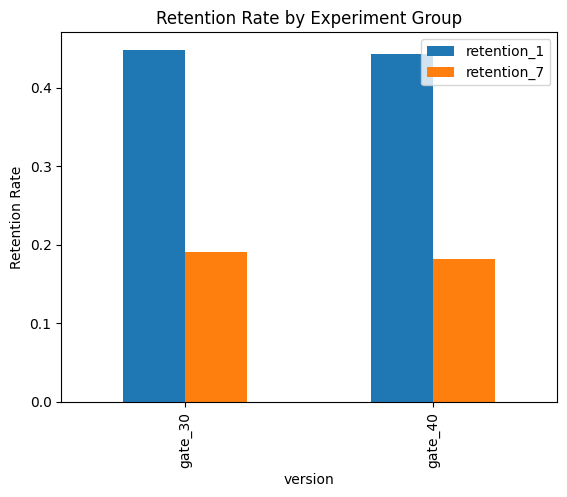

In [7]:
retention.plot(kind='bar')
plt.title("Retention Rate by Experiment Group")
plt.ylabel("Retention Rate")
plt.show()

### Insight
- Gate 30 consistently outperforms Gate 40 across both metrics  
- However, differences are relatively small

## 📍 Hypothesis Testing

### Objective
Evaluate whether moving the first gate from level 30 to level 40 impacts player retention.

H₀ : A₁ = A₂  
H₁ : A₁ ≠ A₂  

Where:
- A₁ = retention rate (gate_30)
- A₂ = retention rate (gate_40)

### Significance Level
α = 0.05

We will reject the null hypothesis if the p-value is less than 0.05.

In [8]:
#Statistical Testing

from statsmodels.stats.proportion import proportions_ztest

conv = df.groupby('version')['retention_1'].sum().values
nobs = df.groupby('version')['retention_1'].count().values

z_stat, p_value = proportions_ztest(conv, nobs)

print("Z-stat:", z_stat)
print("P-value:", p_value)

Z-stat: 1.7840862247974725
P-value: 0.07440965529691913


### Interpretation
- The p-value is greater than 0.05  
- We fail to reject the null hypothesis  
- No statistically significant difference detected

In [9]:
retention_diff = (
    retention_summary.loc['gate_30','retention_1_rate'] -
    retention_summary.loc['gate_40','retention_1_rate']
)

print("Retention Difference (Day 1):", retention_diff)

Retention Difference (Day 1): 0.005905169787341458


### Insight
- The effect size is small  
- Even if real, the business impact may be limited

In [10]:
boot_diffs = []

for _ in range(1000):
    sample = df.sample(frac=1, replace=True)
    
    diff = (
        sample[sample['version']=='gate_30']['retention_1'].mean() -
        sample[sample['version']=='gate_40']['retention_1'].mean()
    )
    
    boot_diffs.append(diff)

np.mean(boot_diffs)

np.float64(0.005870147242221716)

### Insight
- Distribution centers near zero  
- Confirms weak or uncertain effect

## Key Findings

- Gate at level 30 shows slightly higher retention than gate at level 40
- However, the difference is NOT statistically significant (p-value = 0.07)
- This suggests the observed difference may be due to random variation


## Business Recommendation

Do NOT move the gate to level 40

## Why?

- Although not statistically significant, the data consistently shows lower retention for gate_40
- There is no evidence that moving the gate improves performance
- Keeping gate_30 is the safer decision to avoid potential decline in engagement

## Conclusion

The p-value (0.07) is above 0.05, so there is no strong evidence that moving the gate to level 40 improves retention. The difference may be due to chance. Since the result is close to significance, further analysis with more data, longer observation, and additional metrics is recommended. For now, keeping the gate at level 30 is the safer choice.